In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import class to analyze MP_Gadget run snapshots
from dm_snapshot_analysis import SnapshotData

In [2]:
snapshot = '/home/aschann/MP-Gadget/DM_Halos_April_7/output/PART_006'

sdata = SnapshotData(snapshot)

/home/aschann/miniconda/envs/test/lib/python3.6/site-packages/bigfile/__init__.py:358: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return pyxbigfile.Dataset.__init__(self, file, dtype=dtype, size=size)


In [3]:
# Example use: get all unique group/halo IDs
sdata.get_all_unique_ids()

Unique group IDs:  [         1          2          3 ...       1984       1985 4294967295]
Total number of group IDs:  1986


In [4]:
# Example use: get array of most statistically significant groups/halos
sigma = 1
target_ids, target_counts = sdata.get_significant_groups(sigma)

print(f"ID for groups above sigma = {sigma}: ", target_ids, "\n")
print("Number of particles in group: ", target_counts)

ID for groups above sigma = 1:  [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192] 

Number of particles in group:  [667 367 357 356 349 349 345 333 328 321 306 304 298 293 275 273 271 266
 261 247 241 241 234 228 226 224 224 221 221 218 217 216 214 211 210 209
 209 206 

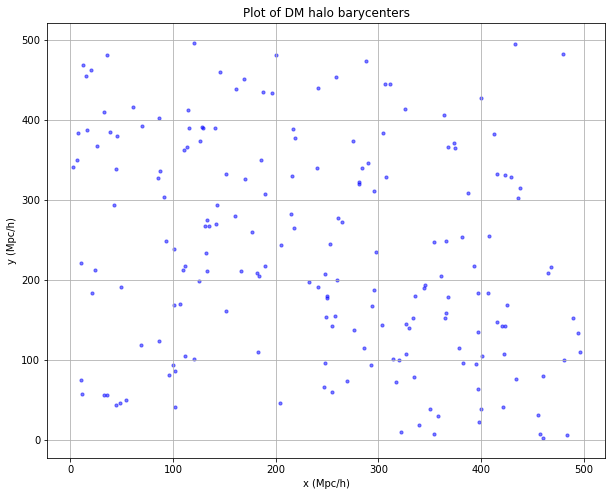

In [5]:
# Example use: Retrieve and plot barycenters of halos
barycenters = sdata.calculate_barycenters(target_ids)

sdata.plot_2D_barycenters(target_ids)

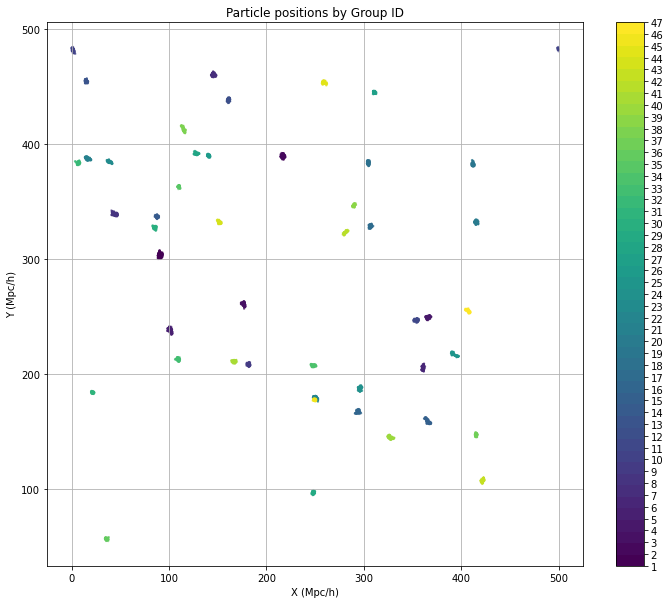

In [6]:
# Example use: Filter particles by group ID, then plot particles for those groups 
target_ids, target_counts = sdata.get_significant_groups(sigma=3)

# returns dictionary of particles with target IDs
target_particles = sdata.filter_particles_by_group(target_ids=target_ids) 

# Plot in 2D
sdata.plot_particle_groups(target_ids=target_ids)

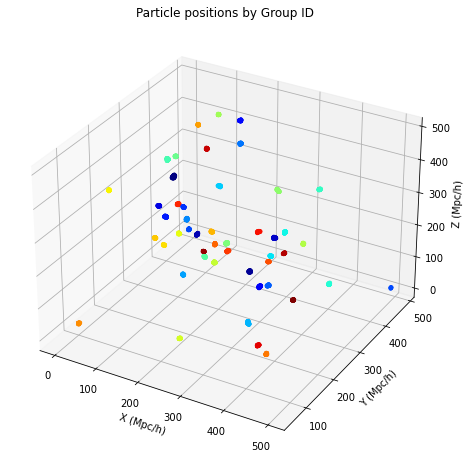

In [7]:
# Example use: Filter particles by group ID, then plot particles for those groups 
target_ids, target_counts = sdata.get_significant_groups(sigma=3)

# returns dictionary of particles with target IDs
target_particles = sdata.filter_particles_by_group(target_ids=target_ids) 

# OR plot in 3D
sdata.plot_3D_particle_groups(target_ids=target_ids)

Closest group IDs to specified points:  [41, 9]


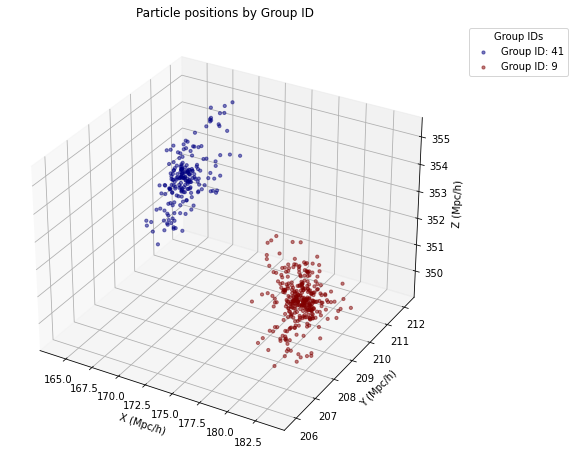

In [8]:
# Example use: Find group ID related to particles near a point of interest

# Looking for group IDs of the two halo groups we chose that are relatively close and isolated 
# -- visualized by above pipeling, notably plotting 2D particle groups of target IDs

points_of_interest = [(167, 209), (182,206)] # indicate points you want to search near as a tuple

# Get dictionary of groups associated to the points we give
target_groups = sdata.find_closest_groups(points_of_interest=points_of_interest)
print("Closest group IDs to specified points: ", target_groups)


# Plot two halos of interest
sdata.plot_3D_particle_groups(target_ids=target_groups, legend=True)

In [13]:
# Angular momentum calculations
L = sdata.calculate_angular_momentum((41,9))
L41 = L[41]
L9 = L[9]

L

{9: array([-4.71834683e+31, -5.24575427e+31, -1.39296898e+32]),
 41: array([1.20813220e+31, 6.60250412e+31, 2.82945266e+31])}

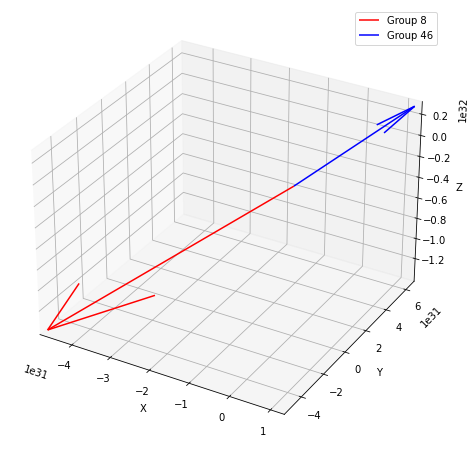

In [14]:
# Plot angular momenta
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

origin = [0,0,0]

ax.quiver(*origin, *L9, color='r', label='Group 8')
ax.quiver(*origin, *L41, color='b', label='Group 46')

ax.set_xlim([min(L9[0], L41[0]), max(L9[0], L41[0])])
ax.set_ylim([min(L9[1], L41[1]), max(L9[1], L41[1])])
ax.set_zlim([min(L9[2], L41[2]), max(L9[2], L41[2])])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.legend()
plt.show()